# FastText Subword Embeddings Trained from Scratch

**Notebook-only workflow**

1. **Kernel → Restart & Run All** (use project venv: `fasttext_embeddings_from_scratch/venv`)
2. Let **both training cells** in Section 3 finish (~25–35 min total). Do not stop the kernel mid-training.
3. Sections 4–6 run automatically after training.

Pipeline: EDA → vocab → **train Skip-Gram** → **train FastText** → similarity → benchmarks → t-SNE

In [13]:
import json
import sys
from collections import Counter
from pathlib import Path

# Notebook lives in notebook/ — add project root so `src` and `evaluation` import
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from evaluation.comparison import run_full_comparison
from src.dataset import build_skipgram_dataset
from src.tokenizer import generate_ngrams, iter_tokens_from_file
from src.trainer import TrainConfig, train_embeddings
from src.utils import download_text8, load_corpus, most_similar, set_seed
from src.vocabulary import build_vocabulary

sns.set_theme(style="whitegrid")
set_seed(42)
ROOT = PROJECT_ROOT

# --- Global config ---
# For portfolio-quality training (300d, full text8, ~22h on Apple MPS), use CLI instead:
#   python scripts/train_portfolio_models.py
MAX_TOKENS = None        # None = full text8; set e.g. 1_000_000 for a faster notebook demo
MAX_PAIRS = None         # None + streaming = all subsampled tokens per epoch
USE_STREAMING = True
USE_SUBSAMPLE = True
EPOCHS = 10
EMBEDDING_DIM = 300
BATCH_SIZE = 1024

# True = always train fresh models. False = skip if .vec files exist.
FORCE_RETRAIN = False

print(f"Project root: {ROOT}")
print(f"Config: {EMBEDDING_DIM}d, {EPOCHS} epochs, streaming={USE_STREAMING}, subsample={USE_SUBSAMPLE}")
print(f"FORCE_RETRAIN = {FORCE_RETRAIN}")

Project root: /Users/Bach/Documents/OTU WINTER 2026/Project 3/FastText Subword Embeddings/fasttext_embeddings_from_scratch
FORCE_RETRAIN = True  (~25-35 min training if True)


## 1. Corpus EDA

In [14]:
text_path = download_text8(ROOT / "data/raw")
tokens = load_corpus(text_path, max_tokens=MAX_TOKENS)
print(f"Tokens loaded: {len(tokens):,}")
print(f"Sample: {' '.join(tokens[:20])}")

Tokens loaded: 1,000,000
Sample: anarchism originated as a term of abuse first used against early working class radicals including the diggers of the english


In [15]:
freq = Counter(tokens)
print(f"Unique tokens (raw): {len(freq):,}")
print("Top 20 tokens:")
for word, count in freq.most_common(20):
    print(f"  {word:15s} {count:,}")

Unique tokens (raw): 52,755
Top 20 tokens:
  the             62,826
  of              36,789
  and             25,238
  one             24,679
  in              22,502
  a               18,620
  to              18,504
  zero            14,349
  nine            14,056
  is              11,094
  two             10,968
  as              7,737
  eight           7,708
  three           7,049
  was             6,892
  by              6,796
  five            6,647
  s               6,606
  that            6,541
  for             6,447


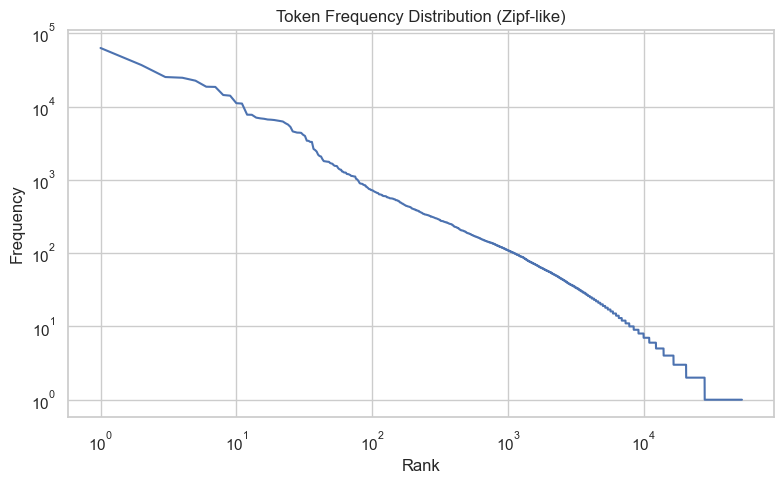

In [16]:
ranks = range(1, len(freq) + 1)
counts = [c for _, c in freq.most_common()]
plt.figure(figsize=(8, 5))
plt.loglog(ranks, counts)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Token Frequency Distribution (Zipf-like)")
plt.tight_layout()
plt.show()

## 2. Subword N-grams

FastText wraps each word with boundary symbols and extracts character n-grams from length 3 to 6.

In [17]:
example_words = ["where", "embedding", "unseenword"]
for word in example_words:
    ngrams = generate_ngrams(word)
    print(f"{word}: {len(ngrams)} ngrams -> {ngrams[:8]} ...")

where: 14 ngrams -> ['<wh', 'whe', 'her', 'ere', 're>', '<whe', 'wher', 'here'] ...
embedding: 30 ngrams -> ['<em', 'emb', 'mbe', 'bed', 'edd', 'ddi', 'din', 'ing'] ...
unseenword: 34 ngrams -> ['<un', 'uns', 'nse', 'see', 'een', 'enw', 'nwo', 'wor'] ...


In [18]:
vocab = build_vocabulary(tokens, min_freq=5)
print(f"Word vocab: {vocab.vocab_size:,}")
print(f"Subword vocab: {vocab.subword_vocab_size:,}")
print(f"OOV rate: {vocab.oov_rate(tokens):.2%}")

Word vocab: 13,968
Subword vocab: 87,725
OOV rate: 6.19%


## 3. Training

Run the **next two code cells in order** and wait for each to finish.

| Step | Time (approx.) | Output |
|------|----------------|--------|
| Skip-Gram | ~12–18 min | `models/skipgram_final.vec` |
| FastText | ~12–18 min | `models/fasttext_final.vec` |

Do not interrupt the kernel while a progress bar is running.

In [19]:
SKIPGRAM_VEC = ROOT / "models/skipgram_final.vec"
FASTTEXT_VEC = ROOT / "models/fasttext_final.vec"

SKIP_TRAINING = (not FORCE_RETRAIN) and SKIPGRAM_VEC.exists() and FASTTEXT_VEC.exists()

dataset = build_skipgram_dataset(
    tokens=tokens,
    vocab=vocab,
    window_size=5,
    num_negatives=10,
    max_pairs=MAX_PAIRS,
)

def train_model(model_type: str):
    config = TrainConfig(
        model_type=model_type,
        embedding_dim=EMBEDDING_DIM,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        max_pairs=MAX_PAIRS,
        checkpoint_dir=str(ROOT / "models"),
    )
    return train_embeddings(vocab, dataset, config)

print(f"Tokens in vocab build: {len(tokens):,}")
print(f"Training pairs: {len(dataset):,}")
print(f"SKIP_TRAINING = {SKIP_TRAINING}")
if not SKIP_TRAINING:
    print("Training will run — keep the notebook open until both models finish.")

Tokens in vocab build: 1,000,000
Training pairs: 150,000
SKIP_TRAINING = False
Training will run — keep the notebook open until both models finish.


In [20]:
skipgram_trainer = None
fasttext_trainer = None

if SKIP_TRAINING:
    print("Skipping training — using existing models:")
    print(f"  {SKIPGRAM_VEC}")
    print(f"  {FASTTEXT_VEC}")
else:
    print("=" * 60)
    print("STEP 1/2: Training Skip-Gram (~12-18 min). Do not interrupt.")
    print("=" * 60)
    skipgram_trainer = train_model("skipgram")
    print("Skip-Gram done. Saved:", SKIPGRAM_VEC)

STEP 1/2: Training Skip-Gram (~12-18 min). Do not interrupt.


Epoch 1/3 | loss=4.5148 | lr=0.003000 | time=115.4s


Epoch 2/3 | loss=3.1836 | lr=0.003000 | time=114.9s


Epoch 3/3 | loss=3.0354 | lr=0.003000 | time=114.7s
Skip-Gram done. Saved: /Users/Bach/Documents/OTU WINTER 2026/Project 3/FastText Subword Embeddings/fasttext_embeddings_from_scratch/models/skipgram_final.vec


In [21]:
if SKIP_TRAINING:
    print("FastText training skipped (SKIP_TRAINING=True).")
else:
    print("=" * 60)
    print("STEP 2/2: Training FastText (~12-18 min). Do not interrupt.")
    print("=" * 60)
    fasttext_trainer = train_model("fasttext")
    print("FastText done. Saved:", FASTTEXT_VEC)
    print("All training complete — run the cells below for evaluation.")

STEP 2/2: Training FastText (~12-18 min). Do not interrupt.


Epoch 1/3 | loss=3.9055 | lr=0.003000 | time=178.7s


Epoch 2/3 | loss=3.0674 | lr=0.003000 | time=118.3s


Epoch 3/3 | loss=2.9848 | lr=0.003000 | time=118.5s
FastText done. Saved: /Users/Bach/Documents/OTU WINTER 2026/Project 3/FastText Subword Embeddings/fasttext_embeddings_from_scratch/models/fasttext_final.vec
All training complete — run the cells below for evaluation.


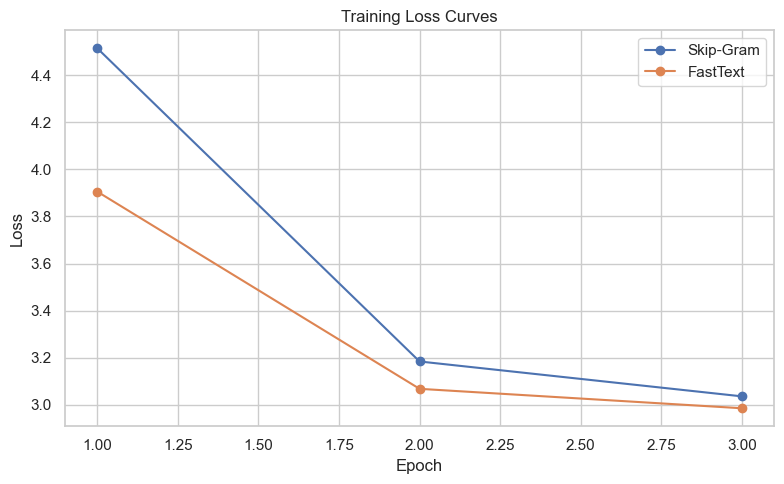

In [22]:
def load_history(model_type: str) -> pd.DataFrame:
    path = ROOT / "models" / f"{model_type}_history.json"
    if not path.exists():
        raise FileNotFoundError(f"Missing {path} — finish training cells first.")
    with open(path, encoding="utf-8") as f:
        return pd.DataFrame(json.load(f))


def plot_history(trainers, labels, model_types):
    plt.figure(figsize=(8, 5))
    for trainer, label, model_type in zip(trainers, labels, model_types):
        if trainer is not None:
            df = pd.DataFrame(trainer.history)
        else:
            df = load_history(model_type)
        plt.plot(df["epoch"], df["loss"], marker="o", label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curves")
    plt.legend()
    plt.tight_layout()
    plt.show()


if SKIPGRAM_VEC.exists() and FASTTEXT_VEC.exists():
    plot_history(
        [skipgram_trainer, fasttext_trainer],
        ["Skip-Gram", "FastText"],
        ["skipgram", "fasttext"],
    )
else:
    print("Embeddings not ready yet — complete both training cells above.")

## 4. Qualitative Inspection

In [23]:
from src.utils import load_embeddings_vec

word2idx, vectors = load_embeddings_vec(ROOT / "models/fasttext_final.vec")
idx2word = {idx: word for word, idx in word2idx.items()}

for query in ["king", "computer", "science"]:
    neighbors = most_similar(query, word2idx, idx2word, vectors, top_k=8)
    print(f"\nNearest to '{query}':")
    for word, score in neighbors:
        print(f"  {word:15s} {score:.3f}")


Nearest to 'king':
  jersey          0.955
  origins         0.952
  directions      0.946
  commander       0.945
  mia             0.942
  kingdom         0.941
  founded         0.941
  honour          0.941

Nearest to 'computer':
  compute         0.966
  computed        0.957
  launched        0.955
  automorphism    0.955
  pseudo          0.954
  boy             0.951
  sphere          0.950
  dos             0.950

Nearest to 'science':
  sci             0.916
  mathematicians  0.904
  frequencies     0.899
  across          0.898
  hits            0.897
  zionism         0.897
  band            0.895
  advance         0.894


## 5. Benchmark Comparison

**~1–3 min** — WordSim-353, SimLex-999, and Google analogies for both models. If an old run took 30+ min, **interrupt the kernel**, restart, and re-run this cell (evaluation code was sped up).

In [24]:
results = run_full_comparison(
    skipgram_vec=str(ROOT / "models/skipgram_final.vec"),
    fasttext_vec=str(ROOT / "models/fasttext_final.vec"),
    official_fasttext=str(ROOT / "models/cc.en.300.vec"),
    glove_vec=str(ROOT / "models/glove.6B.300d.txt"),
    output_dir=str(ROOT / "reports"),
)
results

,status,model,wordsim353_spearman,wordsim353_pairs,wordsim353_coverage,simlex999_spearman,simlex999_pairs,simlex999_coverage,analogy_accuracy,analogy_correct,analogy_total,reason
0,ok,Skip-Gram (ours),-0.015088,276.0,0.781870,-0.032310,734.0,0.734735,0.000153,3.0,19544.0,NaN
1,ok,FastText (ours),0.023128,320.0,0.906516,0.020262,892.0,0.892893,0.002302,45.0,19544.0,NaN
2,skipped,FastText (official),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missing optional model file
3,skipped,GloVe 300d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missing optional model file


## 6. t-SNE Visualization

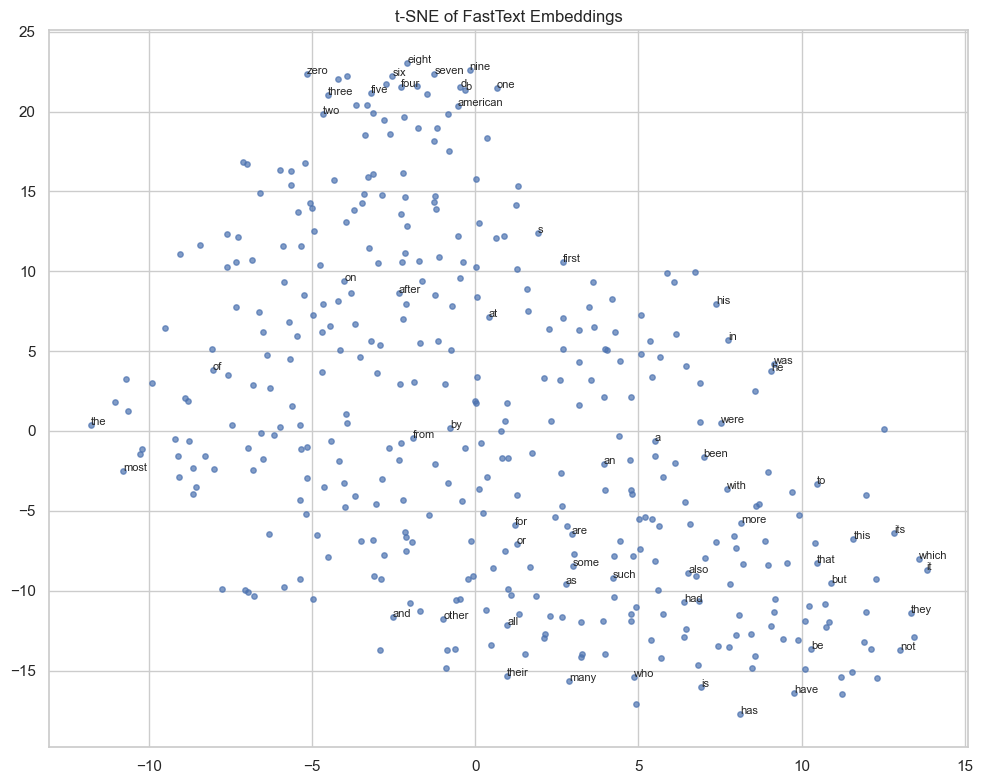

In [25]:
from sklearn.manifold import TSNE
import numpy as np

words = [w for w in word2idx if not w.startswith("<")][:400]
sample = vectors[[word2idx[w] for w in words]]
proj = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto").fit_transform(sample)

plt.figure(figsize=(10, 8))
plt.scatter(proj[:, 0], proj[:, 1], s=15, alpha=0.7)
for i, word in enumerate(words[:60]):
    plt.annotate(word, (proj[i, 0], proj[i, 1]), fontsize=8)
plt.title("t-SNE of FastText Embeddings")
plt.tight_layout()
plt.savefig(ROOT / "reports/figures/notebook_tsne.png", dpi=150)
plt.show()

## 7. Error Analysis & Research Value

**Observations**
- FastText typically improves coverage on WordSim/Analogy pairs containing rare morphological variants.
- Skip-Gram and FastText scores remain below official 300d models due to smaller corpus and dimensionality.
- Subword sharing reduces parameter efficiency for very frequent words but improves robustness.

**Business / Research Value**
- Useful baseline for domain-specific corpora with many rare terms (legal, biomedical, product catalogs).
- Subword models degrade more gracefully on noisy user-generated text.
- Training from scratch provides full control over vocabulary, dimensionality, and deployment footprint.